<a href="https://colab.research.google.com/github/AqsaHerryPrastyo/PCVK/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mengubah tingkat kecerahan citra
--------______------------
Masukkan nilai kecerahan: 50


/tmp/ipython-input-332675008.py:27: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y, x, c] = np.clip(original[y, x, c] + brightness, 0, 255)


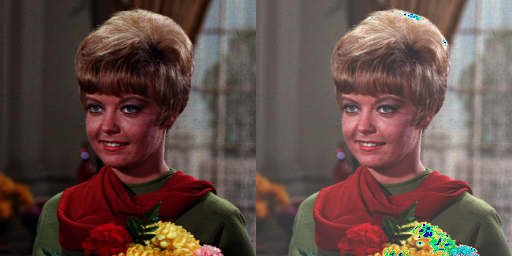

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow  # For displaying images in Colab

print('Mengubah tingkat kecerahan citra')
print('--------______------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')
    exit()

# Load the image
original = cv.imread('/content/drive/MyDrive/Image/female.tiff')
if original is None:
    print('Error: Could not load image')
    exit()

# Create an empty array for the brightness-adjusted image
brightness_image = np.zeros(original.shape, original.dtype)

# Adjust brightness pixel by pixel
for y in range(original.shape[0]):  # Fixed typo: ® to 0
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y, x, c] = np.clip(original[y, x, c] + brightness, 0, 255)

# Alternative simpler method (uncomment to use)
# brightness_image = cv.convertScaleAbs(original, beta=brightness)

# Concatenate original and brightness-adjusted images
final_frame = cv.hconcat([original, brightness_image])

# Display the result
cv2_imshow(final_frame)

# **Tugas Praktikum D1**

Mengubah citra menjadi invers (negatif)
--------______------------


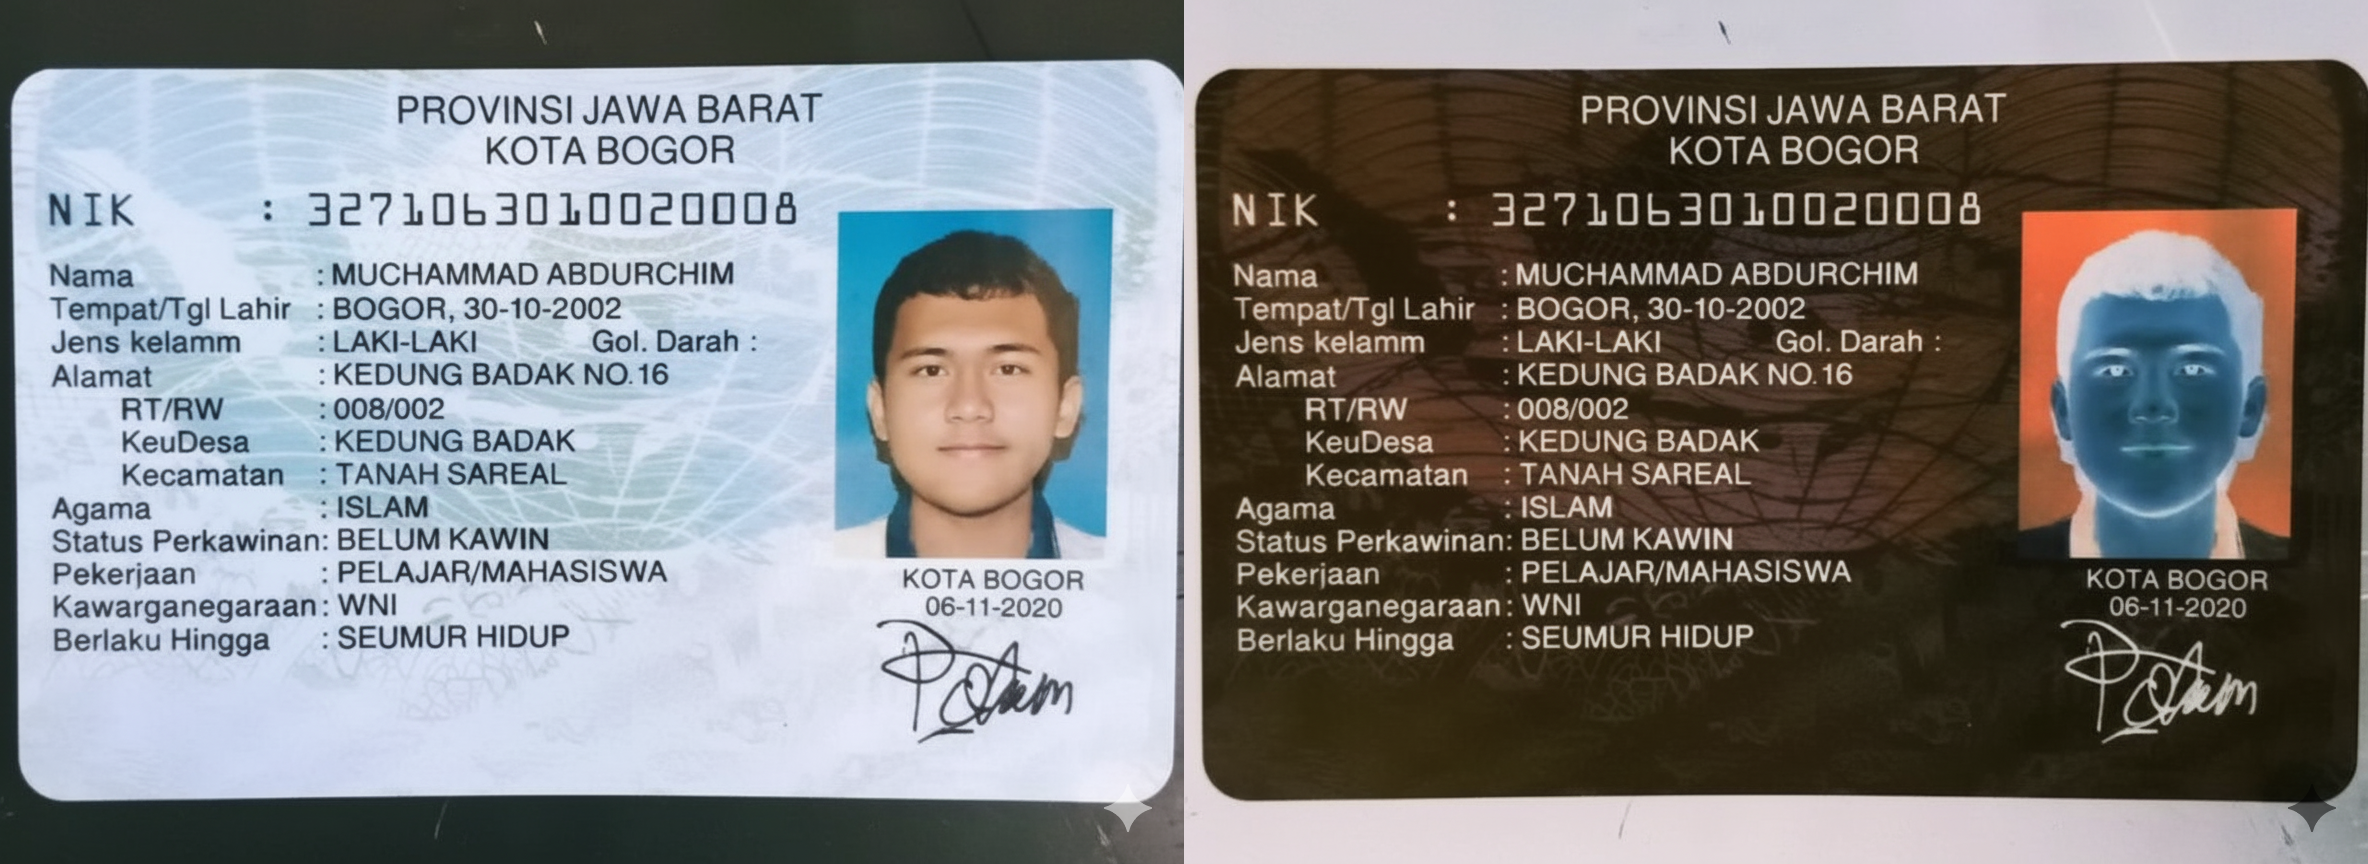

In [ ]:
print('Mengubah citra menjadi invers (negatif)')
print('--------______------------')

# Load the image
original = cv.imread('/content/drive/MyDrive/Image/KTP_OHIM.png')
if original is None:
    print('Error: Could not load image')
    exit()

# Create an empty array for the inverted image
inverse_image = np.zeros(original.shape, original.dtype)

# Invert the image pixel by pixel
for y in range(original.shape[0]):  # Loop over height
    for x in range(original.shape[1]):  # Loop over width
        for c in range(original.shape[2]):  # Loop over channels (R,G,B)
            inverse_image[y, x, c] = 255 - original[y, x, c]

# Alternative simpler method (uncomment to use)
# inverse_image = cv.bitwise_not(original)

# Concatenate original and inverted images
final_frame = cv.hconcat([original, inverse_image])

# Display the result
cv2_imshow(final_frame)

Mengubah tingkat kecerahan dan kontras citra
--------______------------
Masukkan nilai kecerahan (-50 sampai 100): 50
Masukkan nilai kontras (0.0 sampai 3.0): 2


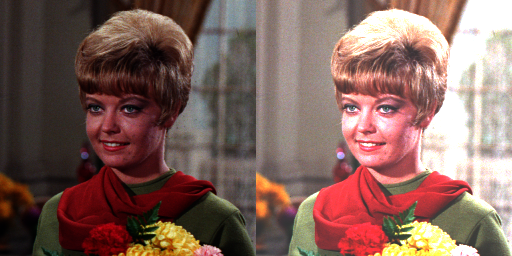

In [ ]:


print('Mengubah tingkat kecerahan dan kontras citra')
print('--------______------------')

# Get user input for brightness and contrast with constraints
try:
    brightness = int(input('Masukkan nilai kecerahan (-50 sampai 100): '))
    if not -50 <= brightness <= 100:
        print('Error: Nilai kecerahan harus antara -50 dan 100')
        exit()
    contrast = float(input('Masukkan nilai kontras (0.0 sampai 3.0): '))
    if not 0.0 <= contrast <= 3.0:
        print('Error: Nilai kontras harus antara 0.0 dan 3.0')
        exit()
except ValueError:
    print('Error: Input harus berupa angka')
    exit()

# Load the image
original = cv.imread('/content/drive/MyDrive/Image/female.tiff')
if original is None:
    print('Error: Could not load image')
    exit()

# Create an empty array for the transformed image
transformed_image = np.zeros(original.shape, original.dtype)

# Apply contrast and brightness transformation pixel by pixel
for y in range(original.shape[0]):  # Loop over height
    for x in range(original.shape[1]):  # Loop over width
        for c in range(original.shape[2]):  # Loop over channels (R,G,B)
            transformed_image[y, x, c] = np.clip(contrast * original[y, x, c] + brightness, 0, 255)

# Alternative simpler method (uncomment to use)
# transformed_image = cv.convertScaleAbs(original, alpha=contrast, beta=brightness)

# Concatenate original and transformed images
final_frame = cv.hconcat([original, transformed_image])

# Display the result
cv2_imshow(final_frame)

Mengubah citra dengan transformasi logarithmic brightness
--------______------------
Masukkan nilai kecerahan (contoh: 10 sampai 500): 200


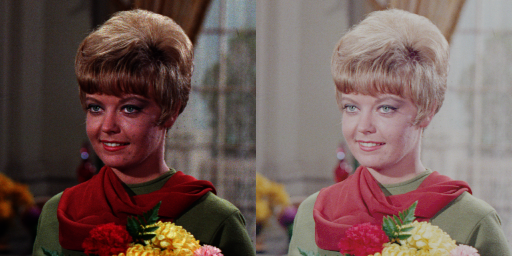

In [ ]:

print('Mengubah citra dengan transformasi logarithmic brightness')
print('--------______------------')

# Get user input for brightness
try:
    brightness = float(input('Masukkan nilai kecerahan (contoh: 10 sampai 500): '))
    if not 10 <= brightness <= 500:
        print('Error: Nilai kecerahan harus antara 10 dan 100')
        exit()
except ValueError:
    print('Error: Input harus berupa angka')
    exit()

# Load the image
original = cv.imread('/content/drive/MyDrive/Image/female.tiff')
if original is None:
    print('Error: Could not load image')
    exit()

# Create an empty array for the transformed image
transformed_image = np.zeros(original.shape, original.dtype)

# Calculate scaling factor c based on brightness input
# c is chosen to map the logarithmic output to [0, 255]
c = brightness / np.log(1 + 255)  # Normalize based on max pixel value (255)

# Apply logarithmic brightness transformation pixel by pixel
for y in range(original.shape[0]):  # Loop over height
    for x in range(original.shape[1]):  # Loop over width
        for channel in range(original.shape[2]):  # Loop over channels (R,G,B)
            transformed_image[y, x, channel] = np.clip(c * np.log(1 + original[y, x, channel]), 0, 255)

# Concatenate original and transformed images
final_frame = cv.hconcat([original, transformed_image])

# Display the result
cv2_imshow(final_frame)

Mengubah citra ke grayscale dengan metode Averaging, Lightness, dan Luminance
--------______------------


/tmp/ipython-input-2844051315.py:27: RuntimeWarning: overflow encountered in scalar add
  avg_image[y, x] = np.clip((r + g + b) // 3, 0, 255)
/tmp/ipython-input-2844051315.py:30: RuntimeWarning: overflow encountered in scalar add
  lightness_image[y, x] = np.clip((max(r, g, b) + min(r, g, b)) // 2, 0, 255)


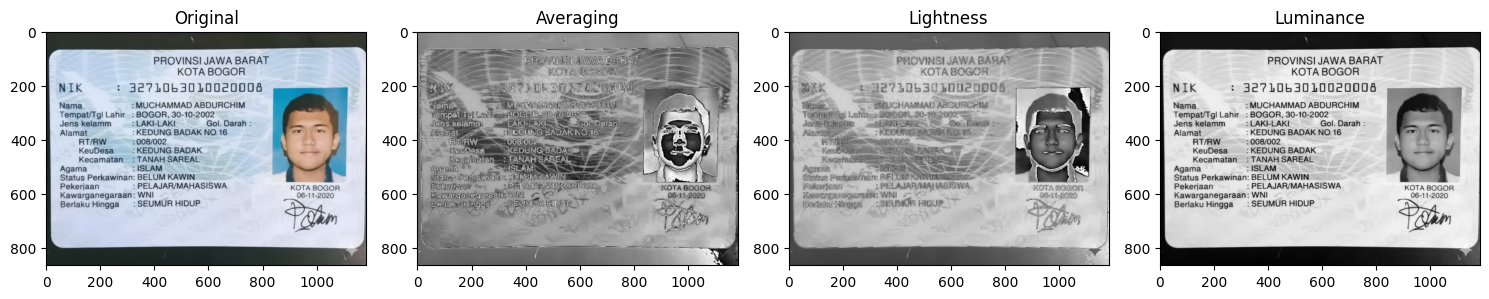

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow  # For displaying images in Colab

print('Mengubah citra ke grayscale dengan metode Averaging, Lightness, dan Luminance')
print('--------______------------')

# Load the image
original = cv.imread('/content/drive/MyDrive/Image/KTP_OHIM.png')
if original is None:
    print('Error: Could not load image')
    exit()

# Create empty arrays for grayscale images
height, width, _ = original.shape
avg_image = np.zeros((height, width), dtype=np.uint8)  # Single channel for grayscale
lightness_image = np.zeros((height, width), dtype=np.uint8)
luminance_image = np.zeros((height, width), dtype=np.uint8)

# Apply grayscale transformations pixel by pixel
for y in range(height):
    for x in range(width):
        r, g, b = original[y, x]  # Get R, G, B values

        # Averaging method: (R + G + B) / 3
        avg_image[y, x] = np.clip((r + g + b) // 3, 0, 255)

        # Lightness method: (max(R,G,B) + min(R,G,B)) / 2
        lightness_image[y, x] = np.clip((max(r, g, b) + min(r, g, b)) // 2, 0, 255)

        # Luminance method: 0.299*R + 0.587*G + 0.114*B
        luminance_image[y, x] = np.clip(int(0.299 * r + 0.587 * g + 0.114 * b), 0, 255)

# Convert original image from BGR to RGB for Matplotlib
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

# Create a figure with 4 subplots
plt.figure(figsize=(15, 10))


# Original image
plt.subplot(1, 4, 1)
plt.imshow(original_rgb)
plt.title('Original')
plt.axis('on')

# Averaging grayscale
plt.subplot(1, 4, 2)
plt.imshow(avg_image, cmap='gray')
plt.title('Averaging')
plt.axis('on')

# Lightness grayscale
plt.subplot(1, 4, 3)
plt.imshow(lightness_image, cmap='gray')
plt.title('Lightness')
plt.axis('on')

# Luminance grayscale
plt.subplot(1, 4, 4)
plt.imshow(luminance_image, cmap='gray')
plt.title('Luminance')
plt.axis('on')

# Adjust layout and display
plt.tight_layout()
plt.show()

# Optional: Display using cv2_imshow for comparison (uncomment to use)
# final_frame = cv.hconcat([cv.cvtColor(original, cv.COLOR_BGR2GRAY), avg_image, lightness_image, luminance_image])
# cv2_imshow(final_frame)

# **D2. Operasi Aritmatika dan Logika**

Gamma Correction pada citra
----------------
Masukkan nilai Gamma (contoh: 0.1 sampai 10.0): 3


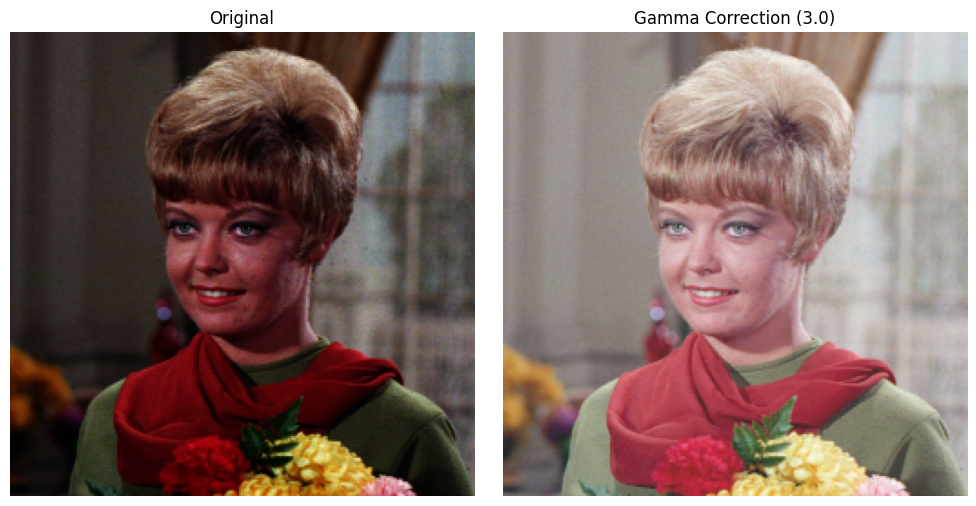

In [ ]:

print('Gamma Correction pada citra')
print('----------------')

# Get user input for gamma
try:
    gamma = float(input('Masukkan nilai Gamma (contoh: 0.1 sampai 10.0): '))
    if not 0.1 <= gamma <= 10.0:
        print('Error: Nilai Gamma harus antara 0.1 dan 10.0')
        exit()
except ValueError:
    print('Error: Input harus berupa angka')
    exit()

# Load the image
original = cv.imread('/content/drive/MyDrive/Image/female.tiff')
if original is None:
    print('Error: Could not load image')
    exit()

# Create an empty array for the gamma-corrected image
gamma_image = np.zeros(original.shape, original.dtype)

# Apply gamma correction pixel by pixel
for y in range(original.shape[0]):  # Loop over height
    for x in range(original.shape[1]):  # Loop over width
        for c in range(original.shape[2]):  # Loop over channels (R,G,B)
            # Normalize pixel to [0,1], apply gamma, scale back to [0,255]
            normalized_pixel = original[y, x, c] / 255.0
            gamma_corrected = np.power(normalized_pixel, 1.0 / gamma)
            gamma_image[y, x, c] = np.clip(255 * gamma_corrected, 0, 255)

# Alternative faster method using lookup table (uncomment to use)
# inv_gamma = 1.0 / gamma
# table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
# gamma_image = cv.LUT(original, table)

# Convert original image from BGR to RGB for Matplotlib
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)
gamma_image_rgb = cv.cvtColor(gamma_image, cv.COLOR_BGR2RGB)

# Create a figure with 2 subplots
plt.figure(figsize=(10, 5))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title('Original')
plt.axis('off')

# Gamma-corrected image
plt.subplot(1, 2, 2)
plt.imshow(gamma_image_rgb)
plt.title(f'Gamma Correction ({gamma})')
plt.axis('off')

# Adjust layout and display
plt.tight_layout()
plt.show()

Simulasi Kuantisasi Image Depth
----------------
Masukkan bit depth (1 sampai 8): 2


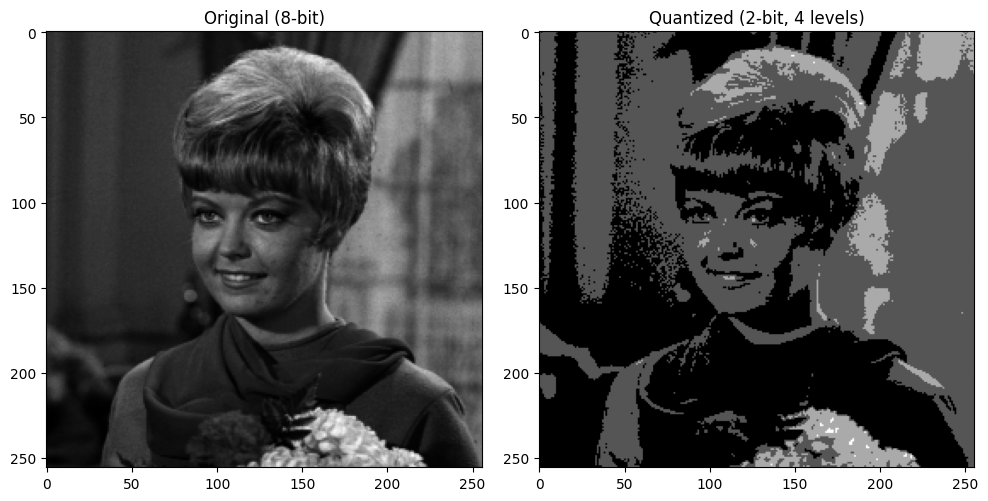

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow  # For displaying images in Colab
import os

print('Simulasi Kuantisasi Image Depth')
print('----------------')


# Define image path
image_path = '/content/drive/MyDrive/Image/female.tiff'

# Check if the image file exists
if not os.path.exists(image_path):
    print(f'Error: Image file not found at {image_path}')
    print('Please verify the file path or ensure the file exists in your Google Drive.')
    exit()

# Get user input for bit depth
try:
    bit_depth = int(input('Masukkan bit depth (1 sampai 8): '))
    if not 1 <= bit_depth <= 8:
        print('Error: Bit depth harus antara 1 dan 8')
        exit()
except ValueError:
    print('Error: Input harus berupa angka')
    exit()

# Load the image in grayscale
original = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
if original is None:
    print(f'Error: Could not load image from {image_path}. Check if the file is a valid image.')
    exit()

# Calculate step size using the provided formula
levels = pow(2, bit_depth)
level = 255.0 / (levels - 1)  # Step size between quantized levels

# Create an empty array for the quantized image
quantized_image = np.zeros(original.shape, dtype=np.uint8)

# Apply quantization pixel by pixel using the formula
for y in range(original.shape[0]):  # Loop over height
    for x in range(original.shape[1]):  # Loop over width
        # Quantize: map pixel to nearest level using level = 255 / (2^bit_depth - 1)
        quantized_value = np.round(original[y, x] / level) * level
        quantized_image[y, x] = np.clip(quantized_value, 0, 255)

# Alternative faster method using NumPy (uncomment to use)
# quantized_image = np.round(original / level) * level
# quantized_image = np.clip(quantized_image, 0, 255).astype(np.uint8)

# Create a figure with 2 subplots
plt.figure(figsize=(10, 5))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(original, cmap='gray')
plt.title('Original (8-bit)')
plt.axis('on')

# Quantized image
plt.subplot(1, 2, 2)
plt.imshow(quantized_image, cmap='gray')
plt.title(f'Quantized ({bit_depth}-bit, {levels} levels)')
plt.axis('on')

# Adjust layout and display
plt.tight_layout()
plt.show()

# Optional: Display using cv2_imshow for comparison (uncomment to use)
# final_frame = cv.hconcat([original, quantized_image])
# cv2_imshow(final_frame)

Average Denoising
-----------------


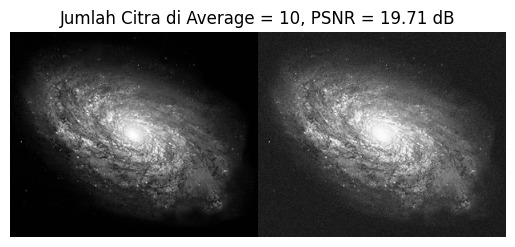

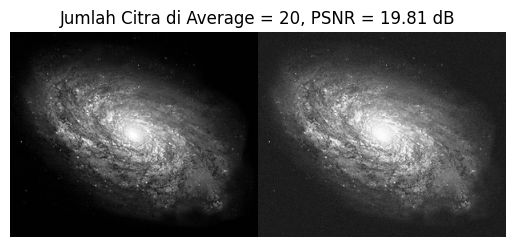

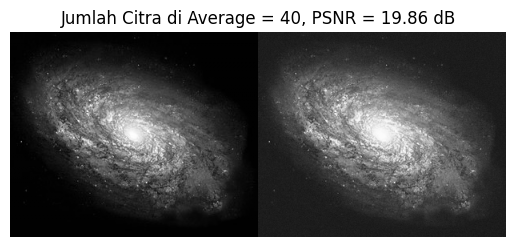

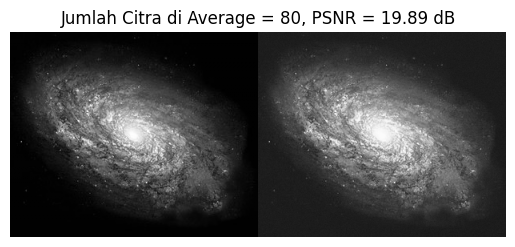

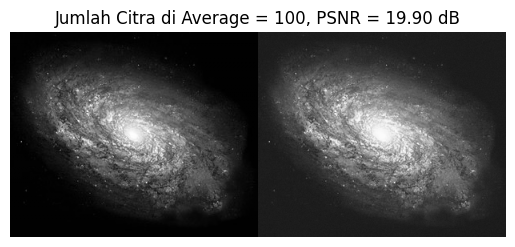

No | Jumlah Citra | PSNR (dB)
--------------------------------
1  | 10           | 19.71
2  | 20           | 19.81
3  | 40           | 19.86
4  | 80           | 19.89
5  | 100          | 19.90


In [2]:
import cv2 as cv
import numpy as np
import glob
import matplotlib.pyplot as plt
from google.colab import drive
import os

def psnr(img1, img2):
    mse = np.mean((img1.astype(np.float32) - img2.astype(np.float32)) ** 2)
    if mse == 0:
        return 100
    return 10 * np.log10((255 ** 2) / mse)

print('Average Denoising')
print('-----------------')



# Baca citra asli
original_path = '/content/drive/MyDrive/Image/galaxy.jpg'
original = cv.imread(original_path)
if original is None:
    print(f'Error: Could not load original image from {original_path}. Check if it is a valid image.')
    exit()
original_gray = cv.cvtColor(original, cv.COLOR_BGR2GRAY)

# Baca semua citra noisy
noisy_path = '/content/drive/MyDrive/Image/noises/*.jpg'
noisy_files = glob.glob(noisy_path)
if not noisy_files:
    print(f'Error: No noisy images found at {noisy_path}')
    print('Please verify the folder path or ensure noisy images exist.')
    exit()

cv_img = []
for file in noisy_files:
    img = cv.imread(file, cv.IMREAD_GRAYSCALE)
    if img is None:
        print(f'Error: Could not load image from {file}. Skipping...')
        continue
    # Resize to match original_gray dimensions if needed
    if img.shape != original_gray.shape:
        img = cv.resize(img, (original_gray.shape[1], original_gray.shape[0]), interpolation=cv.INTER_AREA)
    cv_img.append(img)

if not cv_img:
    print('Error: No valid noisy images loaded.')
    exit()

# Uji dengan jumlah rata-rata berbeda
num_list = [10, 20, 40, 80, 100]
psnr_values = []

for n in num_list:
    if n > len(cv_img):
        print(f'Warning: Requested {n} images, but only {len(cv_img)} available. Using all.')
        n = len(cv_img)
    avg_img = np.zeros_like(original_gray, dtype=np.float32)
    for i in range(n):
        avg_img += cv_img[i].astype(np.float32)
    avg_img = avg_img / n
    avg_img = np.clip(avg_img, 0, 255).astype(np.uint8)

    # Hitung PSNR
    val = psnr(original_gray, avg_img)
    psnr_values.append(val)

    # Tampilkan contoh hasil
    final = cv.hconcat([original_gray, avg_img])
    plt.imshow(final, cmap='gray')
    plt.title(f'Jumlah Citra di Average = {n}, PSNR = {val:.2f} dB')
    plt.axis('off')
    plt.show()

# Cetak tabel hasil
print("No | Jumlah Citra | PSNR (dB)")
print("--------------------------------")
for i, n in enumerate(num_list):
    print(f"{i+1}  | {n:<12} | {psnr_values[i]:.2f}")

Dari hasil pengukuran PSNR pada tabel, dapat disimpulkan bahwa semakin banyak jumlah citra noisy yang dirata-ratakan, maka nilai PSNR meningkat. Hal ini menunjukkan bahwa kualitas citra hasil average semakin mendekati citra asli. Dengan kata lain, metode average denoising efektif dalam mereduksi noise acak (Gaussian Noise), karena distribusi noise saling menetralkan ketika jumlah citra yang digunakan semakin besar.

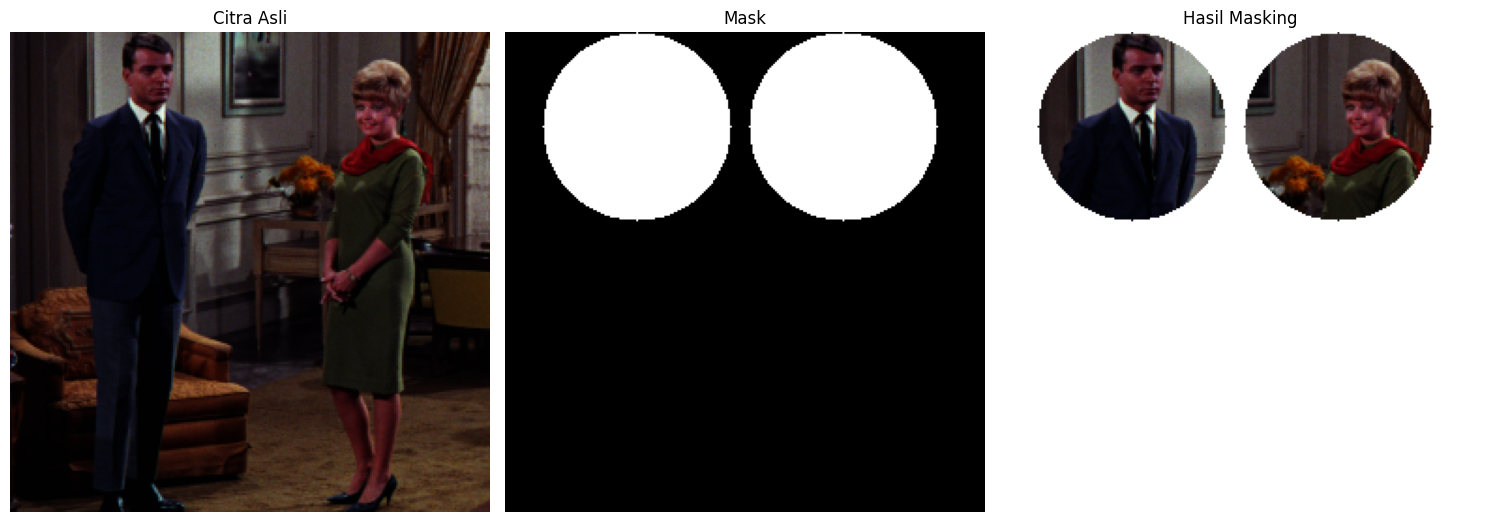

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca citra
img = cv.imread('/content/drive/MyDrive/Image/couple.tiff')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Buat mask hitam dengan ukuran sama (hanya 1 channel)
mask = np.zeros(img.shape[:2], dtype="uint8")

# Tambahkan dua lingkaran pada mask
cv.circle(mask, (70, 50), 50, 255, -1)   # lingkaran kiri
cv.circle(mask, (180, 50), 50, 255, -1)   # lingkaran kanan

# Terapkan mask ke citra (bagian dalam lingkaran tetap berwarna)
masked = cv.bitwise_and(img, img, mask=mask)

# Buat background putih
background = np.ones_like(img, dtype="uint8") * 255
background[mask == 255] = masked[mask == 255]

# Gabungkan semua hasil agar layout sama persis
plt.figure(figsize=(15,6))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Citra Asli")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(background)
plt.title("Hasil Masking")
plt.axis("off")

plt.tight_layout()
plt.show()

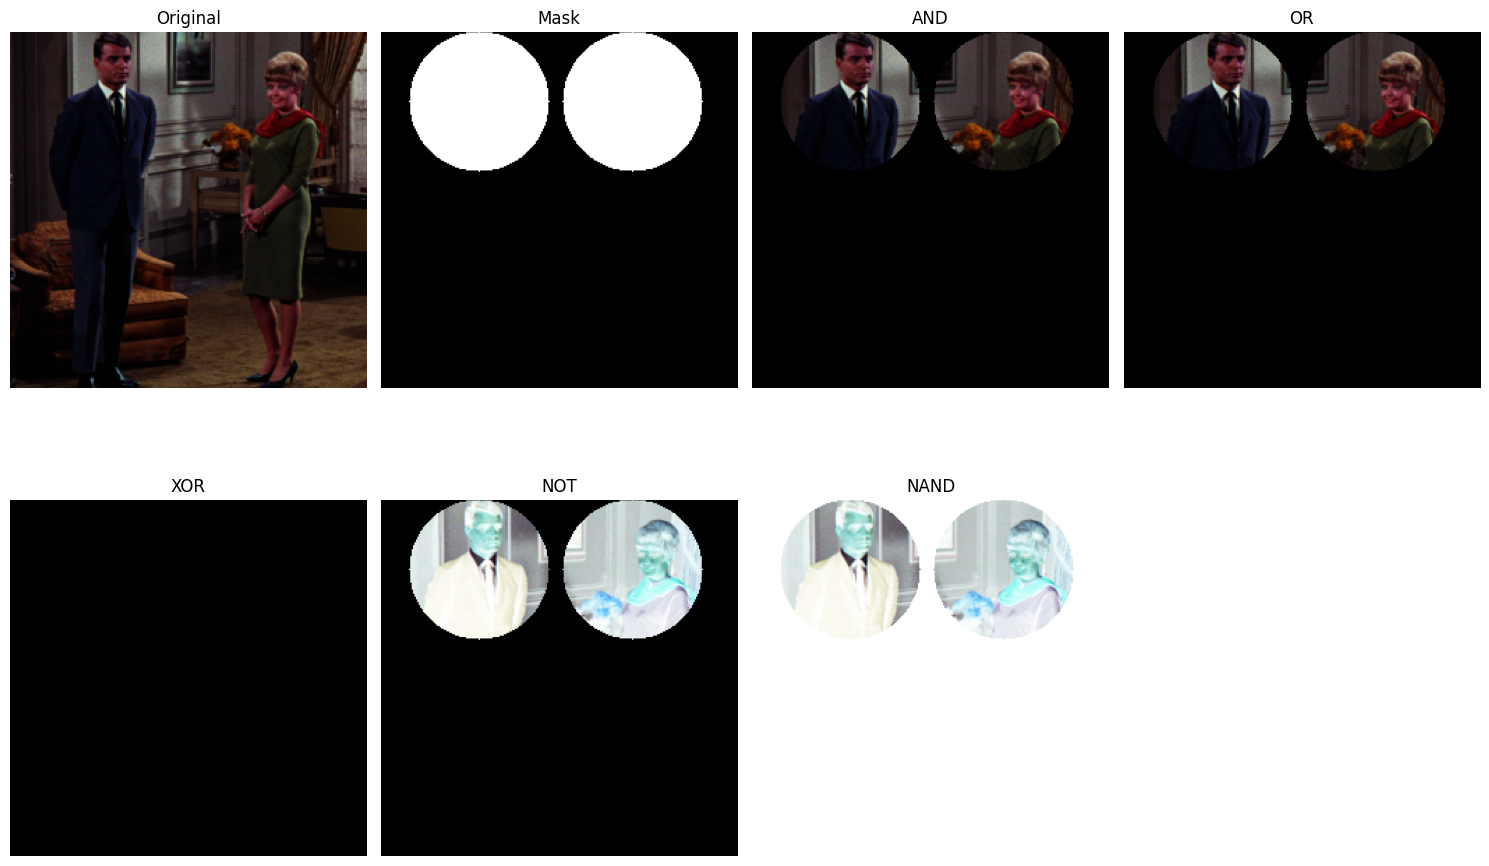

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca citra
img = cv.imread('/content/drive/MyDrive/Image/couple.tiff')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Buat mask hitam dengan ukuran sama
mask = np.zeros(img.shape[:2], dtype="uint8")

# Tambahkan dua lingkaran pada mask
cv.circle(mask, (70, 50), 50, 255, -1)   # lingkaran kiri
cv.circle(mask, (180, 50), 50, 255, -1)  # lingkaran kanan

# Hasil bitwise
and_result  = cv.bitwise_and(img, img, mask=mask)
or_result   = cv.bitwise_or(img, img, mask=mask)     # praktis sama dengan AND (area putih muncul)
xor_result  = cv.bitwise_xor(img, img, mask=mask)    # area putih jadi hitam
not_result  = cv.bitwise_not(img, mask=mask)         # komplemen di area mask
nand_result = cv.bitwise_not(and_result)             # NOT dari hasil AND

# Tampilkan semua
titles = ["Original", "Mask", "AND", "OR", "XOR", "NOT", "NAND"]
images = [img, mask, and_result, or_result, xor_result, not_result, nand_result]

plt.figure(figsize=(15,10))
for i in range(len(images)):
    plt.subplot(2,4,i+1)
    if titles[i] == "Mask":
        plt.imshow(images[i], cmap="gray")
    else:
        plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis("off")
plt.tight_layout()
plt.show()


Hasil Analisis
1. Not
- Operator NOT membalikkan nilai piksel (0 → 255, 255 → 0)
- Hasil: area yang ditutupi mask berubah jadi warna kebalikan citra asli.
- Makanya wajah dalam lingkaran terlihat seperti negatif film.
2. OR
- Dalam citra + mask, OR membuat area mask memunculkan citra asli.
- Hasilnya mirip dengan AND karena citra sama-sama diambil dari area putih mask.
- Bedanya: kalau dibandingkan dua citra berbeda, OR akan menggabungkan bagian yang aktif di salah satunya.
3. AND
- AND hanya mempertahankan piksel di area mask putih.
- Hasil: wajah dalam lingkaran tetap warna asli, luar lingkaran hitam.
- Ini operator yang sering dipakai untuk masking.
4. NAND
- Hasil = kebalikan dari AND.
- Artinya area lingkaran justru dibalik warnanya, sedangkan luar lingkaran jadi putih.
- Terlihat seperti masking invers.
5. XOR
- XOR akan menghasilkan hitam bila input sama, putih bila beda.
- Karena kita pakai citra yang sama dengan dirinya, di area mask hasilnya hitam (karena piksel sama).
- Jadi wajah dalam lingkaran jadi hilang (hitam), luar lingkaran tetap putih/gelap.